In [1]:
import numpy as np
import pandas as pd
import os

from pathlib import Path

def resolve_data_dir() -> Path:
    """Locate the dataset locally or on Kaggle."""
    candidates = [
        Path("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge"),
        Path("../data"),
        Path("data"),
        Path("."),
    ]
    for path in candidates:
        if (path / "train.csv").exists():
            return path
    raise FileNotFoundError(
        "Could not find train.csv. Place the CSVs in ../data (from notebooks/) "
        "or keep the default Kaggle input path."
    )

DATA_DIR = resolve_data_dir()
print("Using data directory:", DATA_DIR.resolve())


/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_log_error
from xgboost import XGBRegressor

# Loading the Dataset

In [3]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
metadata = pd.read_csv(DATA_DIR / "metadata.csv")

print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('Metadata shape:', metadata.shape)


Train shape: (138701, 50)
Test shape: (15000, 49)
Metadata shape: (50, 2)


In [4]:
train.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [5]:
print('Training rows:', train.shape[0])
print('Training columns:', train.shape[1])
print('Test rows:', test.shape[0])
print('\nColumn names:')
print(train.columns.tolist())

Training rows: 138701
Training columns: 50
Test rows: 15000

Column names:
['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID', 'DataOriginCode', 'VendorPartnerID', 'ManufactureYear', 'OperationalHoursMeter', 'UtilizationTier', 'TransactionDate', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18', 'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27', 'col28', 'col29', 'col30']


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [7]:
metadata

,Variable,Rephrased Description
0,TransactionID,A unique serial number assigned to each indivi...
1,TargetValue,"The financial amount of the transaction, denom..."
2,AssetID,The internal tracking number assigned to a spe...
3,ProductConfigID,A system-generated code representing the techn...
4,DataOriginCode,A code indicating the specific software or pla...
5,VendorPartnerID,The unique ID of the external entity or third-...
6,TransactionDate,The official calendar date when the entry was ...
7,RegionCode,The specific geographic area or legal jurisdic...
8,ManufactureYear,The year the asset was originally produced.
9,OperationalHoursMeter,The lifetime total of active run-time or work ...


# Exploratory Data Analysis

In [8]:
print('Target Variable (TargetValue) Summary:')
print(train['TargetValue'].describe())

Target Variable (TargetValue) Summary:
count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64


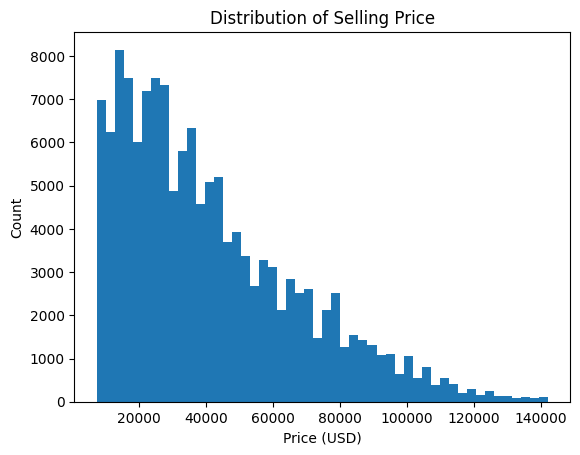

In [9]:
plt.hist(train['TargetValue'], bins=50)
plt.title('Distribution of Selling Price')
plt.xlabel('Price (USD)')
plt.ylabel('Count')
plt.show()

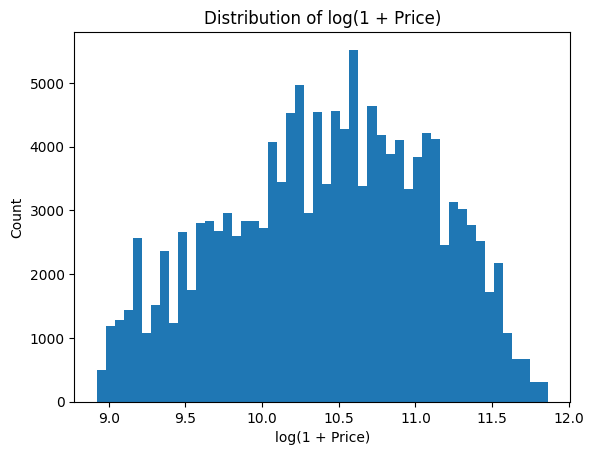

In [10]:
plt.hist(np.log1p(train['TargetValue']), bins=50)
plt.title('Distribution of log(1 + Price)')
plt.xlabel('log(1 + Price)')
plt.ylabel('Count')
plt.show()

In [11]:
missing_count = train.isnull().sum()
missing_pct = (missing_count / len(train) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print(f'Columns with missing values: {len(missing_pct)} out of {train.shape[1]}')
print('\nTop 15 columns with highest missing %:')
print(missing_pct.head(15).round(2))

Columns with missing values: 35 out of 50

Top 15 columns with highest missing %:
col19    99.95
col18    99.95
col5     92.52
col4     92.52
col27    89.21
col28    89.21
col29    86.39
col30    86.39
col13    83.13
col14    83.13
col7     83.13
col6     83.13
col9     83.13
col8     83.13
col11    83.13
dtype: float64


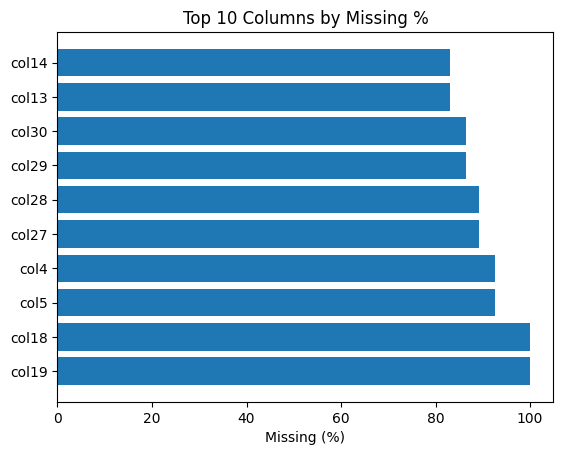

In [12]:
top_missing = missing_pct.head(10)

plt.barh(top_missing.index, top_missing.values)
plt.title('Top 10 Columns by Missing %')
plt.xlabel('Missing (%)')
plt.show()

In [13]:
print('Duplicate TransactionID:', train['TransactionID'].duplicated().sum())
print('Duplicate rows (all columns):', train.duplicated().sum())
print('\nManufactureYear value counts (checking errors):')
print(train['ManufactureYear'].value_counts().tail(10))

Duplicate TransactionID: 0
Duplicate rows (all columns): 0

ManufactureYear value counts (checking errors):
ManufactureYear
1952    3
1953    3
1951    2
1960    2
1954    2
1949    1
1955    1
2013    1
2014    1
2015    1
Name: count, dtype: int64


In [14]:
num_cols_eda = ['ManufactureYear', 'OperationalHoursMeter']
print(train[num_cols_eda].describe())

       ManufactureYear  OperationalHoursMeter
count    138701.000000           8.205800e+04
mean       1891.640853           4.553719e+03
std         306.992001           2.792204e+04
min        1001.000000           0.000000e+00
25%        1990.000000           0.000000e+00
50%        1998.000000           1.620000e+03
75%        2004.000000           5.001000e+03
max        2015.000000           1.729600e+06


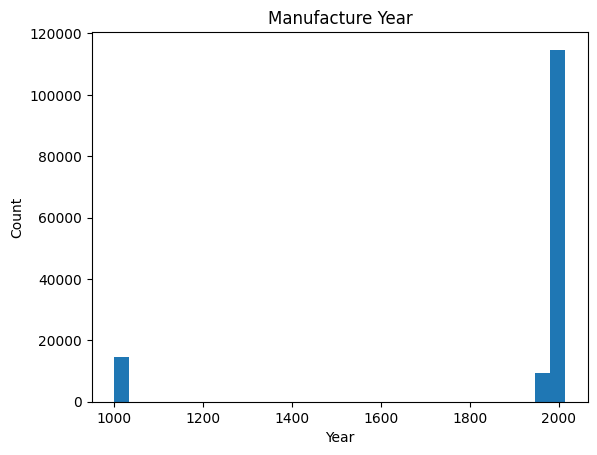

In [15]:
plt.hist(train['ManufactureYear'], bins=30)
plt.title('Manufacture Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

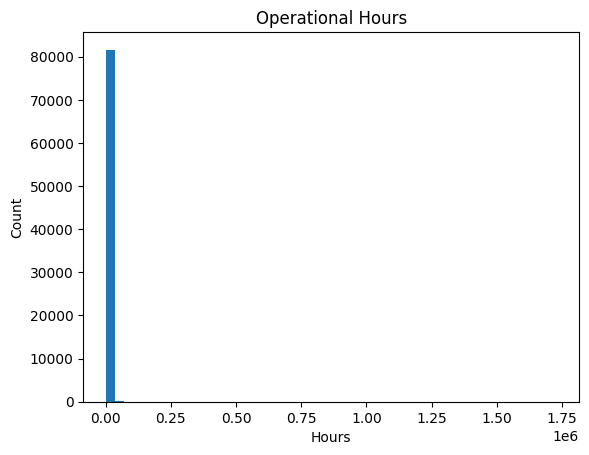

In [16]:
plt.hist(train['OperationalHoursMeter'].dropna(), bins=50)
plt.title('Operational Hours')
plt.xlabel('Hours')
plt.ylabel('Count')
plt.show()

In [17]:
print('UtilizationTier counts:')
print(train['UtilizationTier'].value_counts(dropna=False))
print('\nInventoryGroupCategory counts:')
print(train['InventoryGroupCategory'].value_counts())
print('\nRegionCode — top 10:')
print(train['RegionCode'].value_counts().head(10))
print('\nSpec_BaseClass — unique values:', train['Spec_BaseClass'].nunique())

UtilizationTier counts:
UtilizationTier
NaN       88226
Medium    24588
Low       17005
High       8882
Name: count, dtype: int64

InventoryGroupCategory counts:
InventoryGroupCategory
TEX    71018
MG     23405
WL     18872
TTT    14959
BL     10381
SSL       66
Name: count, dtype: int64

RegionCode — top 10:
RegionCode
Florida           23460
Texas             18284
California         9525
Washington         6063
Georgia            5240
North Carolina     4391
Maryland           4352
Mississippi        4227
Colorado           3989
Illinois           3855
Name: count, dtype: int64

Spec_BaseClass — unique values: 1249


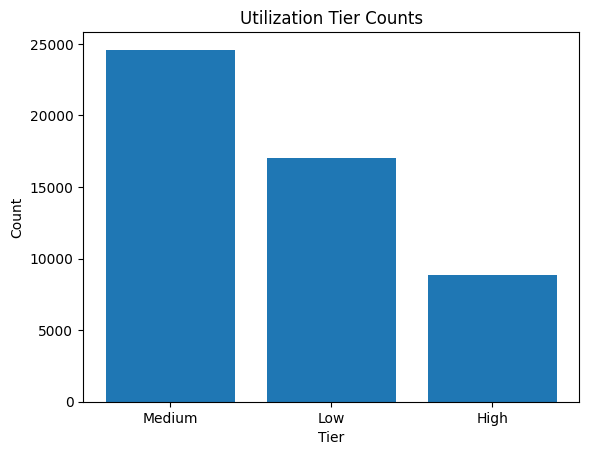

In [18]:
util_counts = train['UtilizationTier'].value_counts()
plt.bar(util_counts.index, util_counts.values)
plt.title('Utilization Tier Counts')
plt.xlabel('Tier')
plt.ylabel('Count')
plt.show()

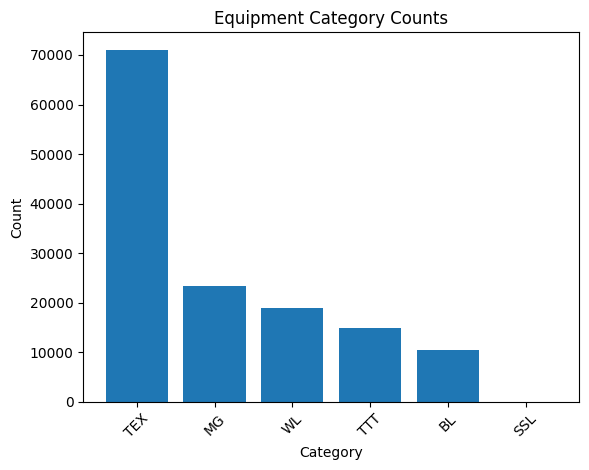

In [19]:
cat_counts = train['InventoryGroupCategory'].value_counts()
plt.bar(cat_counts.index, cat_counts.values)
plt.title('Equipment Category Counts')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

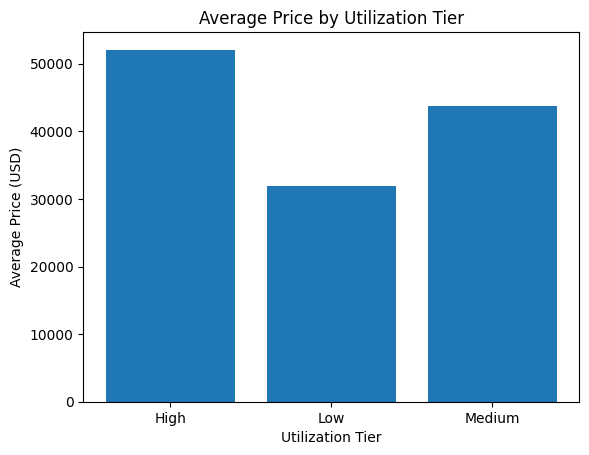

In [20]:
util_price = train.groupby('UtilizationTier')['TargetValue'].mean()

plt.bar(util_price.index, util_price.values)
plt.title('Average Price by Utilization Tier')
plt.xlabel('Utilization Tier')
plt.ylabel('Average Price (USD)')
plt.show()

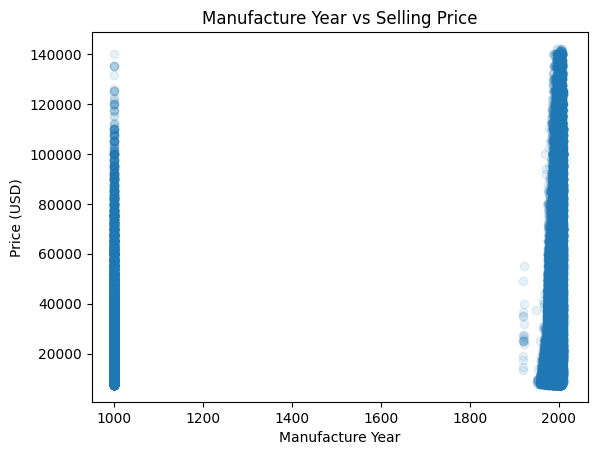

In [21]:
plt.scatter(train['ManufactureYear'], train['TargetValue'], alpha=0.1)
plt.title('Manufacture Year vs Selling Price')
plt.xlabel('Manufacture Year')
plt.ylabel('Price (USD)')
plt.show()

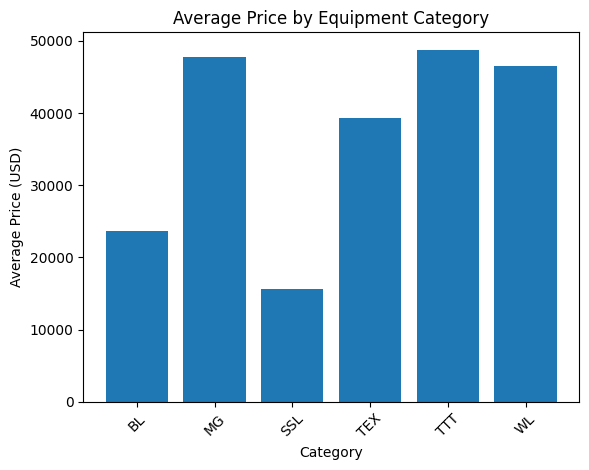

In [22]:
cat_price = train.groupby('InventoryGroupCategory')['TargetValue'].mean()

plt.bar(cat_price.index, cat_price.values)
plt.title('Average Price by Equipment Category')
plt.xlabel('Category')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=45)
plt.show()

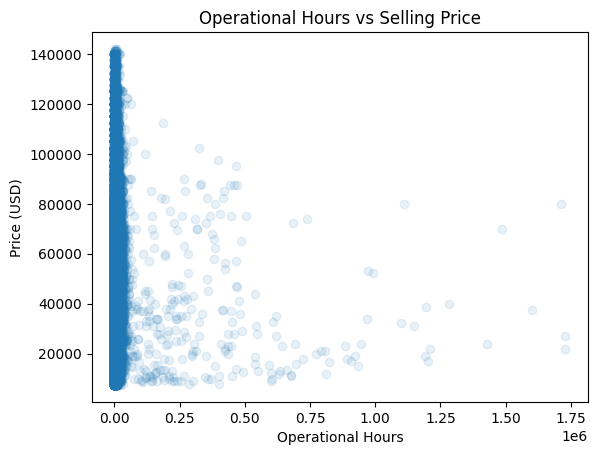

In [23]:
sample = train.dropna(subset=['OperationalHoursMeter'])

plt.scatter(sample['OperationalHoursMeter'], sample['TargetValue'], alpha=0.1)
plt.title('Operational Hours vs Selling Price')
plt.xlabel('Operational Hours')
plt.ylabel('Price (USD)')
plt.show()

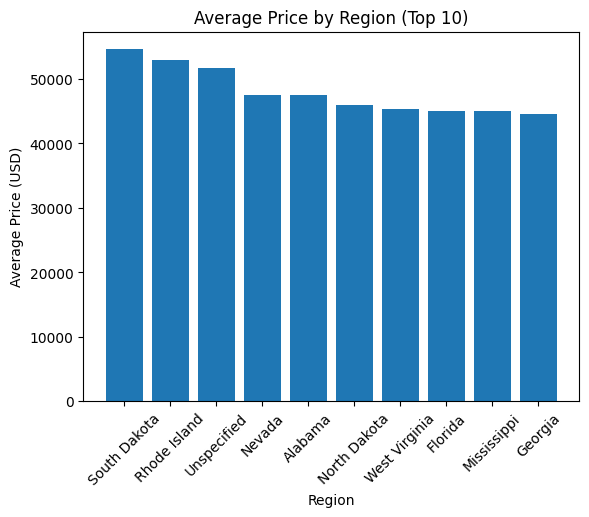

In [24]:
region_price = train.groupby('RegionCode')['TargetValue'].mean().sort_values(ascending=False).head(10)

plt.bar(region_price.index, region_price.values)
plt.title('Average Price by Region (Top 10)')
plt.xlabel('Region')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=45)
plt.show()

In [25]:
corr_data = train[['TargetValue', 'ManufactureYear', 'OperationalHoursMeter']].copy()
corr_data['ManufactureYear'] = corr_data['ManufactureYear'].replace(1001, np.nan)

print('Correlation with TargetValue:')
print(corr_data.corr()['TargetValue'].sort_values(ascending=False))

Correlation with TargetValue:
TargetValue              1.000000
ManufactureYear          0.276962
OperationalHoursMeter    0.001994
Name: TargetValue, dtype: float64


# Feature Engineering

In [26]:
def add_basic_features(df):
    df = df.copy()

    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')
    df['TransactionYear'] = df['TransactionDate'].dt.year
    df['TransactionMonth'] = df['TransactionDate'].dt.month

    df['ManufactureYear'] = df['ManufactureYear'].replace(1001, np.nan)
    df['MachineAge'] = (df['TransactionYear'] - df['ManufactureYear']).clip(0, 50)

    df['LogHours'] = np.log1p(df['OperationalHoursMeter'].fillna(0))
    df['HasHours'] = df['OperationalHoursMeter'].notna().astype(int)

    return df


def add_mean_price_features(df, reference_df, target_col, cols):
    df = df.copy()
    global_mean = reference_df[target_col].mean()

    for col in cols:
        avg_map = reference_df.groupby(col)[target_col].mean()
        df[f'{col}_avg_price'] = df[col].map(avg_map).fillna(global_mean)

    return df


train_fe = add_basic_features(train)
test_fe = add_basic_features(test)

print('Basic features created.')
print(train_fe[['ManufactureYear', 'TransactionYear', 'MachineAge', 'LogHours', 'HasHours']].head())

Basic features created.
   ManufactureYear  TransactionYear  MachineAge  LogHours  HasHours
0           1997.0             2005         8.0  8.442685         1
1           2005.0             2009         4.0  6.232448         1
2           1994.0             2005        11.0  9.353661         1
3           2002.0             2006         4.0  8.493720         1
4           2009.0             2010         1.0  5.713733         1


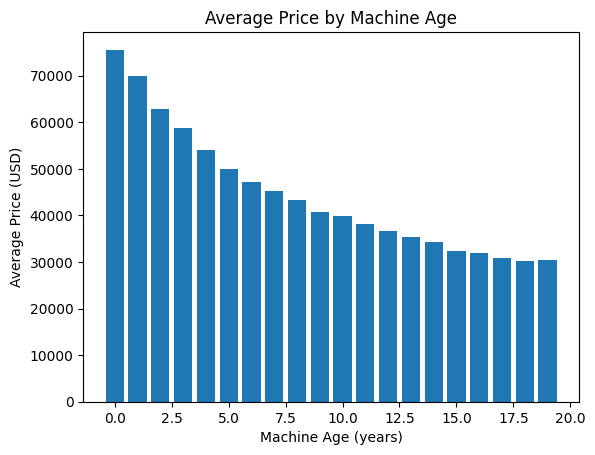

In [27]:
age_price = train.groupby(train_fe['MachineAge'])['TargetValue'].mean().head(20)

plt.bar(age_price.index, age_price.values)
plt.title('Average Price by Machine Age')
plt.xlabel('Machine Age (years)')
plt.ylabel('Average Price (USD)')
plt.show()

# Data Preprocessing

In [28]:
DROP_COLS = [
    'TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID',
    'Spec_FullDescriptor', 'InventoryGroupDescription', 'TransactionDate'
]

MISSING_THRESHOLD = 0.95

MEAN_ENCODE_COLS = [
    'Spec_BaseClass', 'RegionCode', 'InventoryGroupCategory',
    'Spec_SubClass', 'FunctionalClassification', 'CabinType', 'DrivetrainType'
]

In [29]:
base_feature_cols = train_fe.columns.drop(DROP_COLS)
missing_rate = train_fe[base_feature_cols].isnull().mean()
base_feature_cols = missing_rate[missing_rate < MISSING_THRESHOLD].index.tolist()

y = train["TargetValue"]

In [30]:
train_idx, val_idx = train_test_split(train_fe.index, test_size=0.2, random_state=42)

train_part = train_fe.loc[train_idx, base_feature_cols].copy()
val_part = train_fe.loc[val_idx, base_feature_cols].copy()
test_part = test_fe[base_feature_cols].copy()

In [31]:
ref_table = train_part.copy()
ref_table['TargetValue'] = y.loc[train_idx]

train_part = add_mean_price_features(train_part, ref_table, 'TargetValue', MEAN_ENCODE_COLS)
val_part = add_mean_price_features(val_part, ref_table, 'TargetValue', MEAN_ENCODE_COLS)
test_part = add_mean_price_features(test_part, ref_table, 'TargetValue', MEAN_ENCODE_COLS)

feature_cols = train_part.columns.tolist()

X_train = train_part
X_val = val_part
X_test = test_part
y_train = y.loc[train_idx]
y_val = y.loc[val_idx]

In [32]:
full_ref = train_fe[base_feature_cols].copy()
full_ref['TargetValue'] = y
X_full = add_mean_price_features(train_fe[base_feature_cols], full_ref, 'TargetValue', MEAN_ENCODE_COLS)
X_test_final = add_mean_price_features(test_fe[base_feature_cols], full_ref, 'TargetValue', MEAN_ENCODE_COLS)

print('Features selected:', len(feature_cols))
print('Training set:', X_train.shape)
print('Validation set:', X_val.shape)
print('Test set:', X_test_final.shape)

Features selected: 53
Training set: (110960, 53)
Validation set: (27741, 53)
Test set: (15000, 53)


In [33]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in feature_cols if c not in num_cols]

print('Numerical columns (' + str(len(num_cols)) + '):', num_cols)
print('Categorical columns (' + str(len(cat_cols)) + '):', cat_cols)

Numerical columns (14): ['ManufactureYear', 'OperationalHoursMeter', 'TransactionYear', 'TransactionMonth', 'MachineAge', 'LogHours', 'HasHours', 'Spec_BaseClass_avg_price', 'RegionCode_avg_price', 'InventoryGroupCategory_avg_price', 'Spec_SubClass_avg_price', 'FunctionalClassification_avg_price', 'CabinType_avg_price', 'DrivetrainType_avg_price']
Categorical columns (39): ['DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'col1', 'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27', 'col28', 'col29', 'col30']


In [34]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', max_categories=30))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ]
)

# Evaluation Metric

In [35]:
def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))


# Models 

In [36]:
ridge_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, np.log1p(y_train))
ridge_pred = np.expm1(ridge_model.predict(X_val))
ridge_score = rmsle(y_val, ridge_pred)

print(f'Ridge Regression RMSLE: {ridge_score:.4f}')

Ridge Regression RMSLE: 0.3263


In [37]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, np.log1p(y_train))
rf_pred = np.expm1(rf_model.predict(X_val))
rf_score = rmsle(y_val, rf_pred)

print(f'Random Forest RMSLE: {rf_score:.4f}')

Random Forest RMSLE: 0.2323


In [38]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=600,
        max_depth=10,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.7,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, np.log1p(y_train))
xgb_pred = np.expm1(xgb_model.predict(X_val))
xgb_score = rmsle(y_val, xgb_pred)

print(f'XGBoost RMSLE: {xgb_score:.4f}')

XGBoost RMSLE: 0.2072


# Model Comparison

In [39]:
results = pd.DataFrame({
    'Model': ['Ridge Regression', 'Random Forest', 'XGBoost'],
    'Validation RMSLE': [ridge_score, rf_score, xgb_score]
}).sort_values('Validation RMSLE')

print(results.to_string(index=False))

           Model  Validation RMSLE
         XGBoost          0.207222
   Random Forest          0.232272
Ridge Regression          0.326259


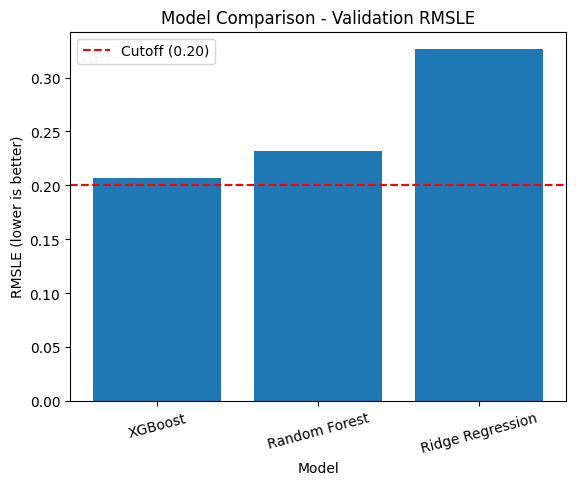

In [40]:
plt.bar(results['Model'], results['Validation RMSLE'])
plt.axhline(y=0.2, color='red', linestyle='--', label='Cutoff (0.20)')
plt.title('Model Comparison - Validation RMSLE')
plt.xlabel('Model')
plt.ylabel('RMSLE (lower is better)')
plt.xticks(rotation=15)
plt.legend()
plt.show()

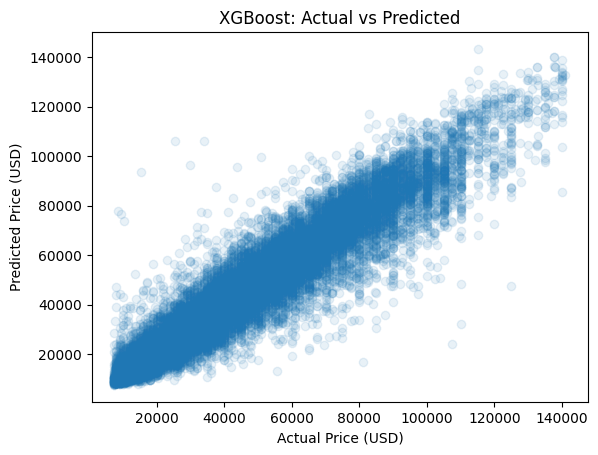

In [41]:
plt.scatter(y_val, xgb_pred, alpha=0.1)
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('XGBoost: Actual vs Predicted')
plt.show()

# Hyperparameter Tuning

In [42]:
param_grid = {
    'model__n_estimators': [600, 800, 1000],
    'model__max_depth': [8, 10],
    'model__learning_rate': [0.03, 0.05],
    'model__subsample': [0.8, 0.9]
}

tune_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(colsample_bytree=0.7, random_state=42, n_jobs=-1))
])

grid_search = GridSearchCV(
    tune_pipeline,
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_log_error',
    n_jobs=-1,
    verbose=1
)

print('Starting hyperparameter tuning...')
grid_search.fit(X_train, np.log1p(y_train))

print('\nBest parameters:')
print(grid_search.best_params_)
print(f'Best CV RMSLE: {-grid_search.best_score_:.4f}')

Starting hyperparameter tuning...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 10, 'model__n_estimators': 1000, 'model__subsample': 0.8}
Best CV RMSLE: 0.0185


In [43]:
best_model = grid_search.best_estimator_
tuned_pred = np.expm1(best_model.predict(X_val))
tuned_score = rmsle(y_val, tuned_pred)

print(f'Tuned XGBoost Validation RMSLE: {tuned_score:.4f}')
print(f'Improvement over untuned XGBoost: {xgb_score - tuned_score:.4f}')

Tuned XGBoost Validation RMSLE: 0.2044
Improvement over untuned XGBoost: 0.0028


# Final Training

In [44]:
best_params = grid_search.best_params_

final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=best_params['model__n_estimators'],
        max_depth=best_params['model__max_depth'],
        learning_rate=best_params['model__learning_rate'],
        subsample=best_params['model__subsample'],
        colsample_bytree=0.7,
        random_state=42,
        n_jobs=-1
    ))
])

print('Training final model on full training data...')
final_model.fit(X_full, np.log1p(y))

Training final model on full training data...


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ManufactureYear',
                                                   'OperationalHoursMeter',
                                                   'TransactionYear',
                                                   'TransactionMonth',
                                                   'MachineAge', 'LogHours',
                                                   'HasHours',
                                                   'Spec_BaseClass_avg_price',
                                                   'RegionCode_avg_price',
                                                   'InventoryGroupCategory...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=10, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=1000, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [45]:
test_predictions = np.expm1(final_model.predict(X_test_final))
test_predictions = np.maximum(test_predictions, 0)

submission = pd.DataFrame({
    'TransactionID': test['TransactionID'],
    'TargetValue': test_predictions
})

submission.to_csv('submission.csv', index=False)

print('Saved: submission.csv')
print(submission.head())

Saved: submission.csv
   TransactionID   TargetValue
0        1139307  67901.023438
1        1139419  72446.367188
2        1139482  33839.343750
3        1139522  20064.464844
4        1139684  12536.705078


In [46]:
import sys
sys.exit()

SystemExit: 

# Milestone 1

**Question 1 (MCQ):** Dataset Dimensions 

In [ ]:
print("Train dataset rows:", train.shape[0])
print("Test dataset rows:", test.shape[0])

**Question 2 (MCQ):** Target Variable Identification 

In [ ]:
set(train.columns) - set(test.columns)

**Question 3 (Numeric):** Feature Data Types

In [ ]:
print(train.select_dtypes(include='number').shape[1])

**Question 4 (MSQ):** Extremely Sparse Columns 

In [ ]:
missing_pct = train.isnull().mean() * 100

sparse_cols = missing_pct[missing_pct > 90]

print(f"Number of columns with >90% missing values: {len(sparse_cols)}")
print(sparse_cols.sort_values(ascending=False))

**Question 5 (Numeric):** Missing Operational Metrics 

In [ ]:
missing_count = train['OperationalHoursMeter'].isna().sum()
total_rows = len(train)

missing_pct = (missing_count / total_rows) * 100

print("Missing values:", missing_count)
print("Percentage missing:", round(missing_pct, 2), "%")

**Question 6 (MCQ):** Target Value Distribution 

In [ ]:
median_price = train['TargetValue'].median()
print(f"Median TargetValue: {median_price:,.0f}")

**Question 7 (Numeric):** Manufacture Year Anomaly

In [ ]:
train['ManufactureYear'].mode()

**Question 8 (MCQ):** Time Span of Transactions 

In [ ]:
train['TransactionDate'] = pd.to_datetime(train['TransactionDate'])

print(train['TransactionDate'].min())

**Question 9 (Numeric):** High Cardinality Identification

In [ ]:
train['Spec_BaseClass'].nunique()

**Question 10 (MCQ):** Geographical Volume 

In [ ]:
train['RegionCode'].value_counts()

**Question 11 (Numeric):** Regional Pricing Insights 

In [ ]:
train[train['RegionCode'] == 'Florida']['TargetValue'].mean()

**Question 12 (MCQ):** Asset Utilization 

In [ ]:
train['UtilizationTier'].value_counts()

**Question 13 (MCQ):** Operational Correlation

In [ ]:
train[['TargetValue', 'OperationalHoursMeter']].corr(method='pearson')

**Question 14 (MCQ):** Primary Equipment Types

In [ ]:
train['FunctionalClassification'].mode()[0]

# Milestone 2

**Question 1**

In [ ]:
train["TransactionDate"] = pd.to_datetime(train["TransactionDate"])

In [ ]:
train["TransactionYear"] = train["TransactionDate"].dt.year
train["TransactionQuarter"] = train["TransactionDate"].dt.quarter

In [ ]:
train["AssetAge"] = train["TransactionYear"] - train["ManufactureYear"]

In [ ]:
train["DescriptorLength"] = (
    train["Spec_FullDescriptor"]
    .fillna("")
    .astype(str)
    .str.len()
)

In [ ]:
train["HasOperationalHours"] = train["OperationalHoursMeter"].notna().astype(int)
train["HasVariantModifier"] = train["Spec_VariantModifier"].notna().astype(int)

In [ ]:
most_frequent_asset_age = train["AssetAge"].mode()[0]
print("Most frequent AssetAge:", most_frequent_asset_age)

**Question 2**

In [ ]:
quarter_avg = train.groupby("TransactionQuarter")["TargetValue"].mean()
print("Average TargetValue by Quarter:")
print(quarter_avg.idxmax())

**Question 3**

In [ ]:
print("Maximum DescriptorLength:", train["DescriptorLength"].max())

**Question 4**

In [ ]:
count_operational = train["HasOperationalHours"].sum()
print("HasOperationalHours = 1:", count_operational)

**Question 5**

In [ ]:
variant_percent = train["HasVariantModifier"].mean() * 100
print("Percentage with Variant Info: {:.2f}%".format(variant_percent))

**Question 6**

In [ ]:
mean_year = train["ManufactureYear"].mean()
print("Mean ManufactureYear: {:.2f}".format(mean_year))

**Question 7**

In [ ]:
encoded = pd.get_dummies(
    train,
    columns=["RegionCode", "CabinType", "UtilizationTier"],
    drop_first=True
)

region_cols = pd.get_dummies(train["RegionCode"], drop_first=True).shape[1]
cabin_cols = pd.get_dummies(train["CabinType"], drop_first=True).shape[1]
util_cols = pd.get_dummies(train["UtilizationTier"], drop_first=True).shape[1]

total_encoded = region_cols + cabin_cols + util_cols

In [ ]:
print("Encoded Columns Created:", total_encoded)

**Question 8**

In [ ]:
numeric_cols = train.select_dtypes(include=np.number)
corr = numeric_cols.corr(method="pearson")
target_corr = corr["TargetValue"].abs().sort_values(ascending=False)

In [ ]:
print(target_corr)

**Question 9**

In [ ]:
features = ["ManufactureYear", "OperationalHoursMeter", "AssetAge"]

X = train[features].copy()
y = train["TargetValue"]

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
print("Training Shape:", X_train.shape)

**Question 10**

In [ ]:
print("Validation Shape:", X_valid.shape)

**Question 11**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X2 = train[["ManufactureYear", "AssetAge"]]

X2 = SimpleImputer(strategy="mean").fit_transform(X2)
X2 = StandardScaler().fit_transform(X2)

X_train2, X_valid2, y_train2, y_valid2 = train_test_split(
    X2,
    y,
    test_size=0.20,
    random_state=42
)

model = LinearRegression()
model.fit(X_train2, y_train2)

pred = model.predict(X_valid2)

r2 = r2_score(y_valid2, pred)

print("R2 Score:", r2)

# Milestone 3

**Question 1**

In [ ]:
train_df = train.copy()

In [ ]:
train_df["TransactionDate"] = pd.to_datetime(train_df["TransactionDate"])

train_df["SaleYear"] = train_df["TransactionDate"].dt.year

mode_sale_year = train_df["SaleYear"].mode()[0]

print(mode_sale_year)

**Question 2**

In [ ]:
train_df["ManufactureYear"] = train_df["ManufactureYear"].replace([1000, 1001], np.nan)

train_df["AssetAge"] = train_df["SaleYear"] - train_df["ManufactureYear"]

median_age = train_df["AssetAge"].median()

print(median_age)

**Question 3**

In [ ]:
missing_fraction = train_df.isna().mean()

cols_to_drop = missing_fraction[missing_fraction > 0.80]

print("Columns to drop:", len(cols_to_drop))
print(cols_to_drop.index.tolist())

**Question 4**

Median

**Question 5**

In [ ]:
filled = train_df["CabinType"].fillna("Missing")

missing_count = (filled == "Missing").sum()

print(missing_count)

**Question 6**

In [ ]:
train_df["HoursPerYear"] = (
    train_df["OperationalHoursMeter"] /
    train_df["AssetAge"]
)

train_df["HoursPerYear"] = train_df["HoursPerYear"].replace([np.inf, -np.inf], np.nan)

median_hours = train_df["HoursPerYear"].median()

print(median_hours)

**Question 7**

The categorical feature has very high cardinality

**Question 8**

In [ ]:
from sklearn.model_selection import train_test_split

df = train.copy()

X = df.drop(columns=["TargetValue"])
y = df["TargetValue"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape[0])

**Question 9**

In [ ]:
import numpy as np

df = train.copy()

y_log = np.log1p(df["TargetValue"])

print(y_log.std())

**Question 10**

Before applying any scalers, target encoders, or median imputations.

**Question 11**

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

df = train.copy()

enc = OrdinalEncoder()

encoded = enc.fit_transform(df[["UtilizationTier"]])

print(len(enc.categories_[0]))

**Question 12**

Gradient Boosted Trees (LightGBM/XGBoost)

**Question 13**

The total number of individual decision trees built in the ensemble.

**Question 14**

The model used that specific feature frequently to make highly accurate splits in the decision trees, meaning it strongly influences the target prediction.

**Question 15**

It automatically halts training if the validation score stops improving, preventing the model from overfitting to the training data.

# Milestone 4

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

In [ ]:
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH  = DATA_DIR / "test.csv"

train_original = pd.read_csv(TRAIN_PATH)
test_original = pd.read_csv(TEST_PATH)


In [ ]:
train_df = train_original.copy(deep=True)
test_df = test_original.copy(deep=True)

**Question 1**

In [ ]:
train_df["UtilizationTier"] = train_df["UtilizationTier"].fillna("Unknown")

train_df["PriceBand"] = pd.qcut(
    train_df["TargetValue"],
    q=5,
    labels=False
)

X = train_df.drop(columns=["TargetValue"])
y = train_df["TargetValue"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=X["PriceBand"]
)

train_counts = (
    X_train["PriceBand"]
    .value_counts()
    .sort_index()
    .to_numpy()
)

valid_counts = (
    X_valid["PriceBand"]
    .value_counts()
    .sort_index()
    .to_numpy()
)

print("Train counts:", train_counts)
print("Validation counts:", valid_counts)


X_train_ns, X_valid_ns, y_train_ns, y_valid_ns = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=None
)

valid_counts_ns = (
    X_valid_ns["PriceBand"]
    .value_counts()
    .sort_index()
    .to_numpy()
)

print("Validation counts (non-stratified):")
print(valid_counts_ns)


prop_strat = valid_counts / valid_counts.sum()
prop_non = valid_counts_ns / valid_counts_ns.sum()

max_abs_diff = np.max(np.abs(prop_strat - prop_non))

print(round(max_abs_diff,4))

**Question 2**

In [ ]:
categorical_cols = [
    "UtilizationTier",
    "DrivetrainType",
    "CabinType",
    "AssetScaleFactor"
]

numeric_cols = [
    "ManufactureYear",
    "OperationalHoursMeter"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True
                ))
            ]),
            categorical_cols
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="mean")),
                ("scaler", StandardScaler())
            ]),
            numeric_cols
        )
    ],
    remainder="drop"
)

X_train_fit = X_train.drop(columns=["PriceBand"])
X_valid_fit = X_valid.drop(columns=["PriceBand"])

X_train_proc = preprocessor.fit_transform(X_train_fit)
X_valid_proc = preprocessor.transform(X_valid_fit)

print(round(X_train_proc.sum(),3))

**Question 3**

In [ ]:
rf = RandomForestRegressor(random_state=42)

param_dist = {
    "n_estimators":[50,100,200],
    "max_depth":[5,10,15]
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_proc, y_train)

print(search.best_params_["n_estimators"])

**Question 4**

In [ ]:
ada = AdaBoostRegressor(
    n_estimators=50,
    random_state=42
)

ada.fit(X_train_proc, y_train)

variance = np.var(ada.estimator_errors_)

print(round(variance,4))

**Question 5**

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf.fit(X_train_proc, y_train)

importance = rf.feature_importances_

answer = np.argmax(importance)

print(answer)

**Question 6**

In [ ]:
N = X_train_proc.shape[1]

weights = (
    N*128 +
    128*64 +
    64*32 +
    32*1
)

print("Number of features:", N)
print(weights)

**Question 7**

In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(128,64,32),
    activation="relu",
    solver="adam",
    batch_size=32,
    max_iter=5,
    random_state=42
)

mlp.fit(X_train_proc, y_train)

print(round(mlp.loss_,4))

**Question 8**

In [ ]:
modelA = MLPRegressor(
    hidden_layer_sizes=(100,),
    alpha=0.0001,
    max_iter=5,
    random_state=42
)

modelB = MLPRegressor(
    hidden_layer_sizes=(100,),
    alpha=1.0,
    max_iter=5,
    random_state=42
)

modelA.fit(X_train_proc, y_train)
modelB.fit(X_train_proc, y_train)

predA = modelA.predict(X_train_proc)
predB = modelB.predict(X_train_proc)

maeA = mean_absolute_error(y_train, predA)
maeB = mean_absolute_error(y_train, predB)

answer = abs(maeA - maeB)

print(round(answer,4))

**Question 9**

In [ ]:
valid_pred = mlp.predict(X_valid_proc)

mae_valid = mean_absolute_error(
    y_valid,
    valid_pred
)

print(round(mae_valid,4))

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv(DATA_DIR / "train.csv")


In [ ]:
missing = data.columns[data.isnull().any()]
print(missing)